In [1]:
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np

sys.path.insert(0, str(Path.cwd().parent))
from config import DATA_PROCESSED, OUTPUTS_FIGURES

# Consistent color palette: one color per domain, reused across all figures
DOMAINS_ORDERED = [
    "coca-cola.com", "pepsi.com", "drpepper.com", "drinkolipop.com",
    "mcdonalds.com", "wendys.com", "shakeshack.com", "fiveguys.com",
]
PALETTE = {d: c for d, c in zip(DOMAINS_ORDERED, sns.color_palette("tab10", 8))}
LINESTYLE = {"large": "-", "small": "--"}

sns.set_theme(style="whitegrid", font_scale=1.1)

def savefig(name):
    path = OUTPUTS_FIGURES / name
    plt.savefig(path, dpi=150, bbox_inches="tight")
    print(f"Saved: {path}")

## Section 1 — SEO Panel

### Fig 1: Organic Traffic Over Time

Saved: /Users/vince/Projects/BITLab/GEO-exploration/seranking/.worktrees/feat-visualizations/seranking/outputs/figures/fig1_organic_traffic.png


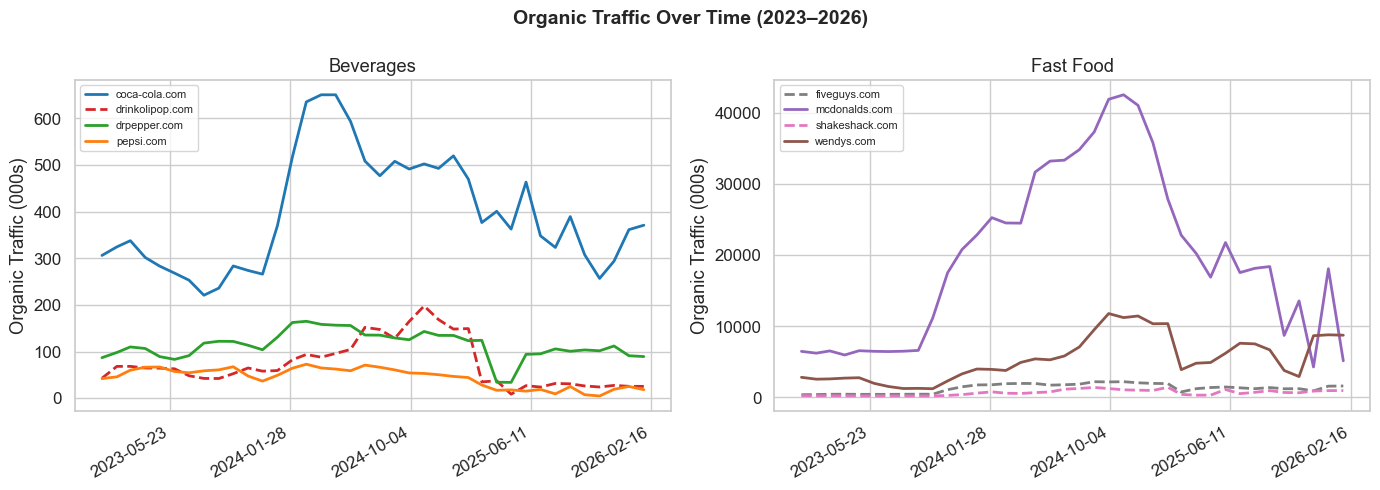

In [2]:
df_seo = pd.read_csv(DATA_PROCESSED / "domain_seo_panel_wide.csv", parse_dates=["date"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)
for ax, (cat, grp) in zip(axes, df_seo.groupby("category")):
    for domain, dgrp in grp.groupby("domain"):
        dgrp = dgrp.sort_values("date")
        ax.plot(dgrp["date"], dgrp["traffic_sum"] / 1_000,
                label=domain, color=PALETTE[domain],
                linestyle=LINESTYLE[dgrp["size_tier"].iloc[0]], linewidth=2)
    ax.set_title(cat.replace("_", " ").title())
    ax.set_xlabel("")
    ax.set_ylabel("Organic Traffic (000s)")
    ax.legend(fontsize=8, loc="upper left")
    ax.xaxis.set_major_locator(mticker.MaxNLocator(6))
    fig.autofmt_xdate()

fig.suptitle("Organic Traffic Over Time (2023\u20132026)", fontsize=14, fontweight="bold")
plt.tight_layout()
savefig("fig1_organic_traffic.png")
plt.show()

### Fig 2: Keyword Count Over Time

Saved: /Users/vince/Projects/BITLab/GEO-exploration/seranking/.worktrees/feat-visualizations/seranking/outputs/figures/fig2_keyword_count.png


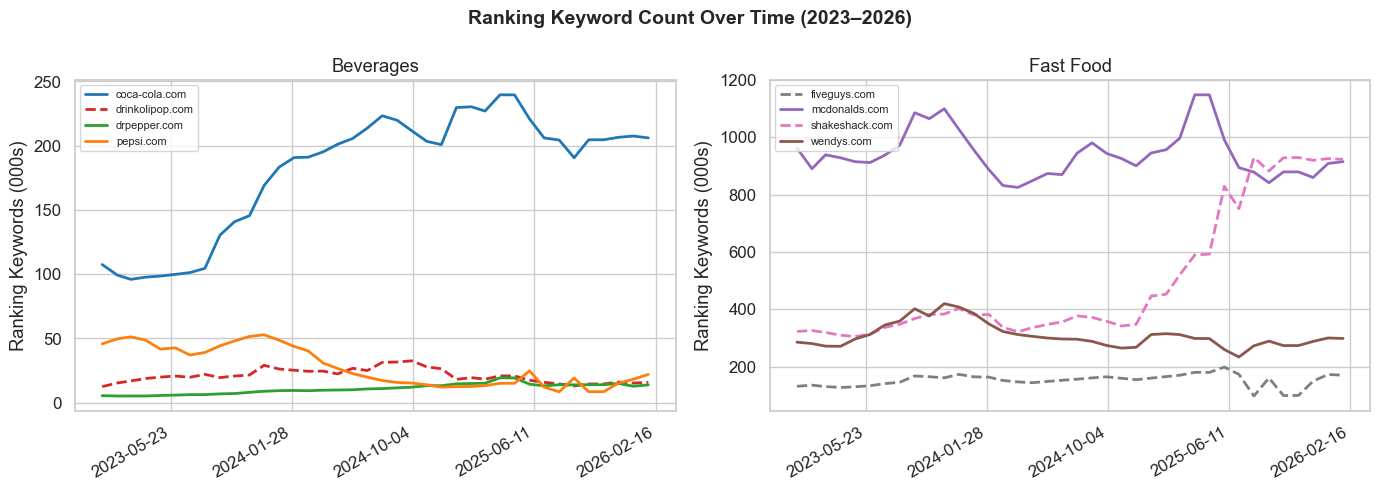

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)
for ax, (cat, grp) in zip(axes, df_seo.groupby("category")):
    for domain, dgrp in grp.groupby("domain"):
        dgrp = dgrp.sort_values("date")
        ax.plot(dgrp["date"], dgrp["keywords_count"] / 1_000,
                label=domain, color=PALETTE[domain],
                linestyle=LINESTYLE[dgrp["size_tier"].iloc[0]], linewidth=2)
    ax.set_title(cat.replace("_", " ").title())
    ax.set_ylabel("Ranking Keywords (000s)")
    ax.legend(fontsize=8, loc="upper left")
    ax.xaxis.set_major_locator(mticker.MaxNLocator(6))
    fig.autofmt_xdate()

fig.suptitle("Ranking Keyword Count Over Time (2023\u20132026)", fontsize=14, fontweight="bold")
plt.tight_layout()
savefig("fig2_keyword_count.png")
plt.show()

### Fig 3: SERP Position Tier Mix Over Time

Saved: /Users/vince/Projects/BITLab/GEO-exploration/seranking/.worktrees/feat-visualizations/seranking/outputs/figures/fig3_position_tiers.png


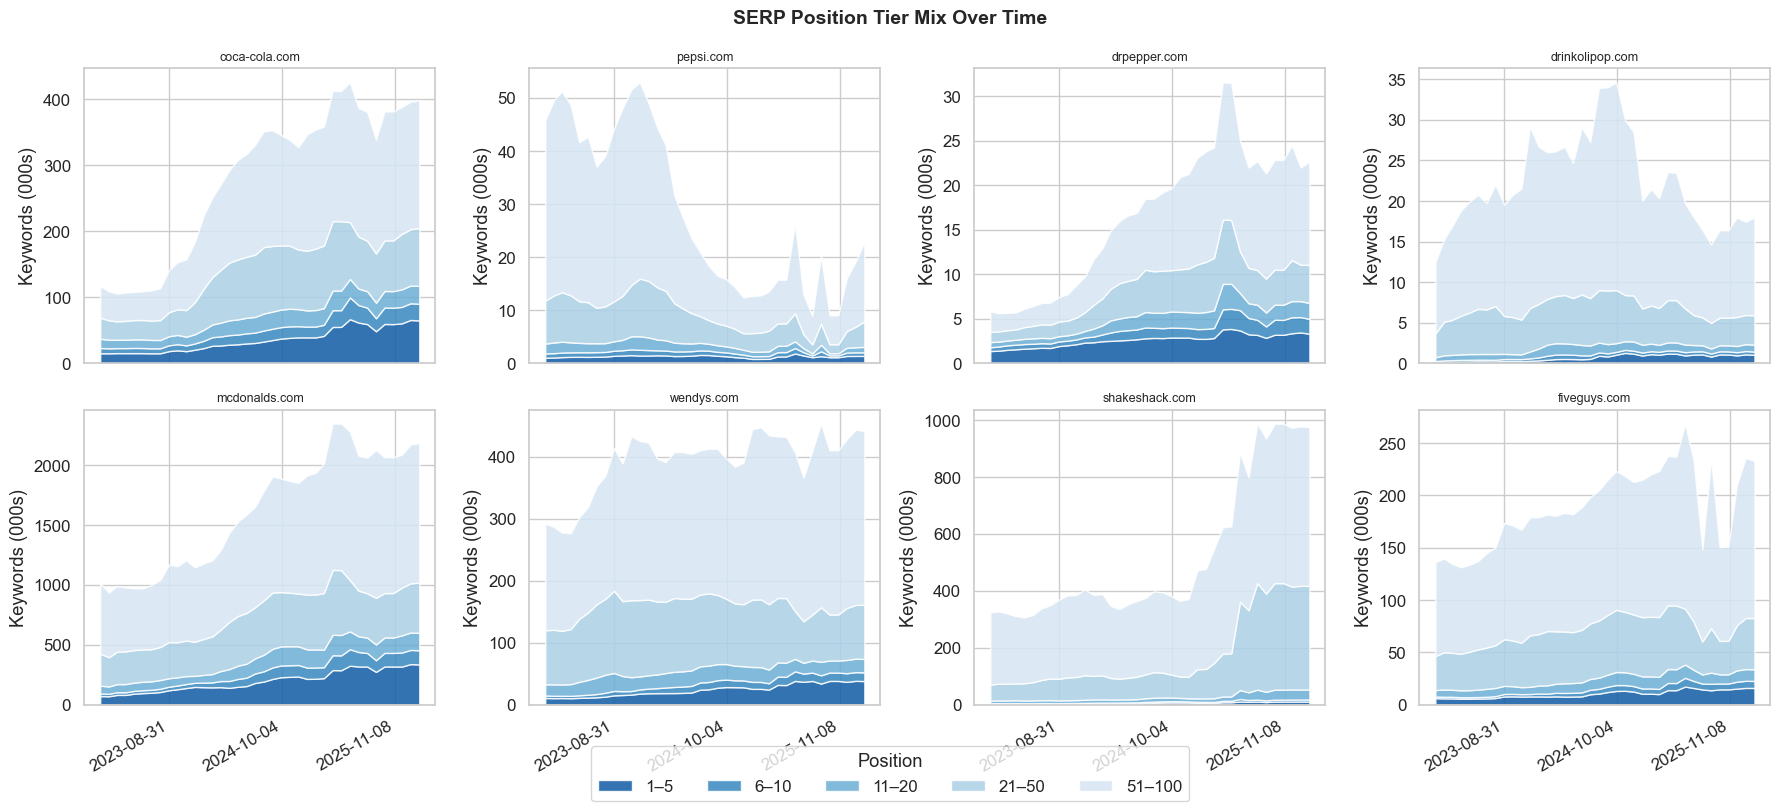

In [4]:
TIER_COLS = ["top1_5", "top6_10", "top11_20", "top21_50", "top51_100"]
TIER_LABELS = ["1\u20135", "6\u201310", "11\u201320", "21\u201350", "51\u2013100"]
TIER_COLORS = sns.color_palette("Blues_r", len(TIER_COLS))

fig, axes = plt.subplots(2, 4, figsize=(18, 8), sharey=False)
axes = axes.flatten()

for ax, domain in zip(axes, DOMAINS_ORDERED):
    dgrp = df_seo[df_seo["domain"] == domain].sort_values("date")
    if dgrp.empty:
        ax.set_visible(False)
        continue
    ax.stackplot(dgrp["date"],
                 [dgrp[c] / 1_000 for c in TIER_COLS],
                 labels=TIER_LABELS, colors=TIER_COLORS, alpha=0.85)
    ax.set_title(domain, fontsize=9)
    ax.set_ylabel("Keywords (000s)")
    ax.xaxis.set_major_locator(mticker.MaxNLocator(4))
    fig.autofmt_xdate()

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="Position", loc="lower center",
           ncol=len(TIER_COLS), bbox_to_anchor=(0.5, -0.02))
fig.suptitle("SERP Position Tier Mix Over Time", fontsize=14, fontweight="bold")
plt.tight_layout()
savefig("fig3_position_tiers.png")
plt.show()

## Section 2 — AI Overview Timeseries

> Note: only the `ai-overview` engine has historical data (Aug 2024 – Feb 2026).

### Fig 4: AI Overview Link Presence Over Time

Saved: /Users/vince/Projects/BITLab/GEO-exploration/seranking/.worktrees/feat-visualizations/seranking/outputs/figures/fig4_aio_link_presence.png


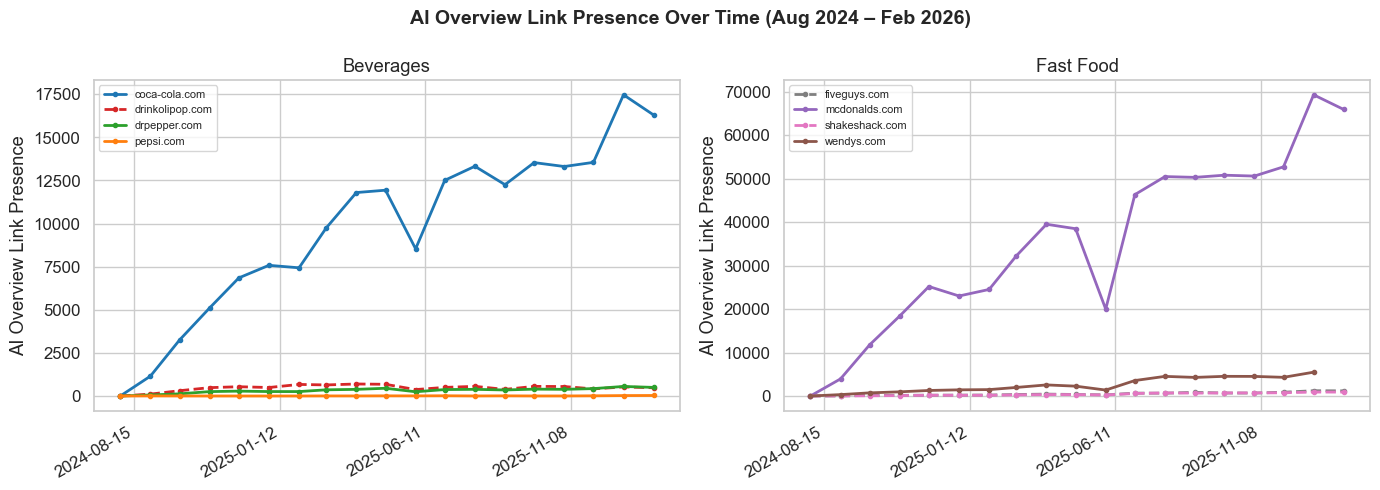

In [5]:
df_ai = pd.read_csv(DATA_PROCESSED / "ai_visibility_timeseries.csv", parse_dates=["date"])
df_aio = df_ai[df_ai["engine"] == "ai-overview"].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)
for ax, (cat, grp) in zip(axes, df_aio.groupby("category")):
    for domain, dgrp in grp.groupby("domain"):
        dgrp = dgrp.sort_values("date")
        ax.plot(dgrp["date"], dgrp["link_presence"],
                label=domain, color=PALETTE[domain],
                linestyle=LINESTYLE[dgrp["size_tier"].iloc[0]], linewidth=2, marker="o", markersize=3)
    ax.set_title(cat.replace("_", " ").title())
    ax.set_ylabel("AI Overview Link Presence")
    ax.legend(fontsize=8, loc="upper left")
    ax.xaxis.set_major_locator(mticker.MaxNLocator(6))
    fig.autofmt_xdate()

fig.suptitle("AI Overview Link Presence Over Time (Aug 2024 \u2013 Feb 2026)", fontsize=14, fontweight="bold")
plt.tight_layout()
savefig("fig4_aio_link_presence.png")
plt.show()

### Fig 5: AI Traffic Share (%) Over Time

Saved: /Users/vince/Projects/BITLab/GEO-exploration/seranking/.worktrees/feat-visualizations/seranking/outputs/figures/fig5_ai_traffic_share.png


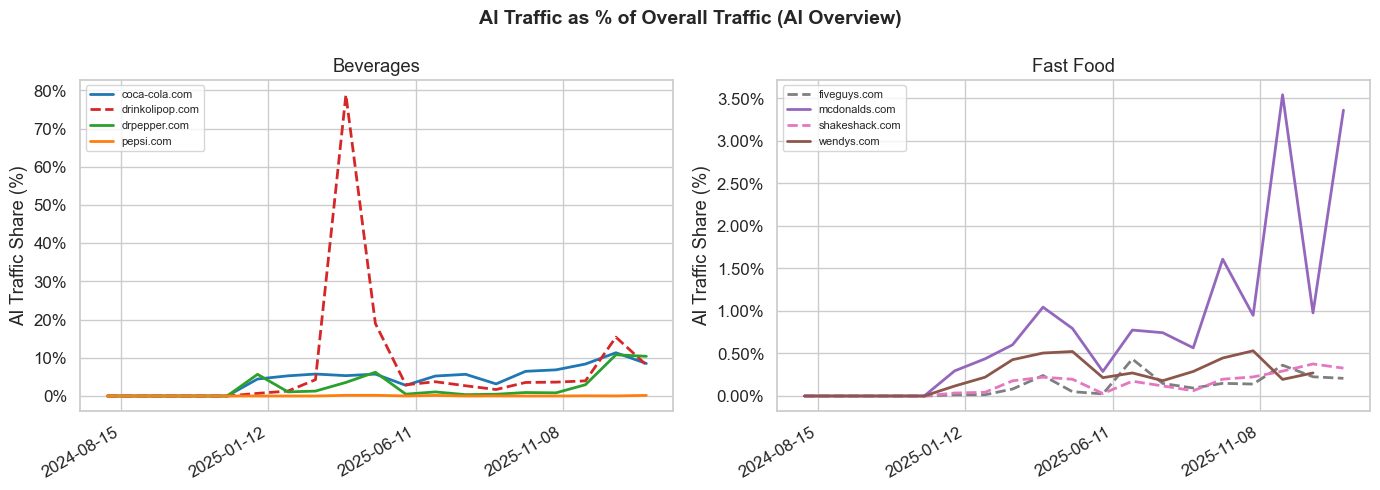

In [6]:
df_aio["ai_share_pct"] = (
    df_aio["ai_traffic"] / df_aio["overall_traffic"].replace(0, np.nan) * 100
).fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)
for ax, (cat, grp) in zip(axes, df_aio.groupby("category")):
    for domain, dgrp in grp.groupby("domain"):
        dgrp = dgrp.sort_values("date")
        ax.plot(dgrp["date"], dgrp["ai_share_pct"],
                label=domain, color=PALETTE[domain],
                linestyle=LINESTYLE[dgrp["size_tier"].iloc[0]], linewidth=2)
    ax.set_title(cat.replace("_", " ").title())
    ax.set_ylabel("AI Traffic Share (%)")
    ax.yaxis.set_major_formatter(mticker.PercentFormatter())
    ax.legend(fontsize=8, loc="upper left")
    ax.xaxis.set_major_locator(mticker.MaxNLocator(6))
    fig.autofmt_xdate()

fig.suptitle("AI Traffic as % of Overall Traffic (AI Overview)", fontsize=14, fontweight="bold")
plt.tight_layout()
savefig("fig5_ai_traffic_share.png")
plt.show()

### Fig 6: Average Position in AI Overview Over Time

Saved: /Users/vince/Projects/BITLab/GEO-exploration/seranking/.worktrees/feat-visualizations/seranking/outputs/figures/fig6_avg_position.png


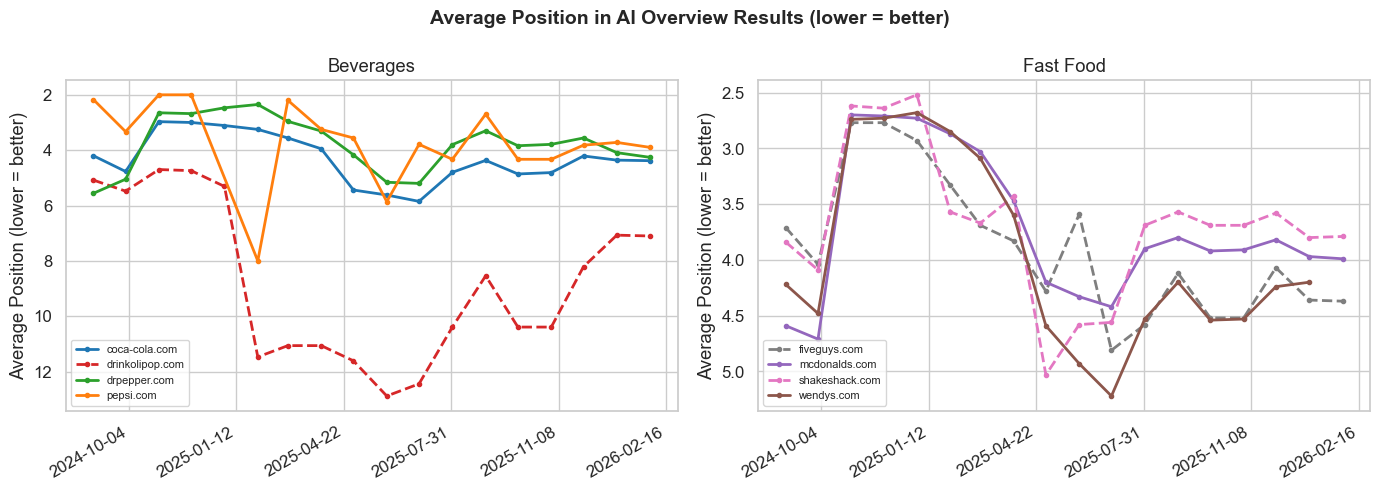

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)
for ax, (cat, grp) in zip(axes, df_aio.groupby("category")):
    for domain, dgrp in grp.groupby("domain"):
        dgrp = dgrp.sort_values("date")
        # Only plot where position > 0 (0 means not present)
        dgrp_present = dgrp[dgrp["average_position"] > 0]
        if dgrp_present.empty:
            continue
        ax.plot(dgrp_present["date"], dgrp_present["average_position"],
                label=domain, color=PALETTE[domain],
                linestyle=LINESTYLE[dgrp["size_tier"].iloc[0]], linewidth=2, marker="o", markersize=3)
    ax.set_title(cat.replace("_", " ").title())
    ax.set_ylabel("Average Position (lower = better)")
    ax.invert_yaxis()
    ax.legend(fontsize=8, loc="lower left")
    ax.xaxis.set_major_locator(mticker.MaxNLocator(6))
    fig.autofmt_xdate()

fig.suptitle("Average Position in AI Overview Results (lower = better)", fontsize=14, fontweight="bold")
plt.tight_layout()
savefig("fig6_avg_position.png")
plt.show()

## Section 3 — Cross-LLM Snapshot

### Fig 7: Link Presence by Domain × Engine (Current Snapshot)

Saved: /Users/vince/Projects/BITLab/GEO-exploration/seranking/.worktrees/feat-visualizations/seranking/outputs/figures/fig7_llm_heatmap.png


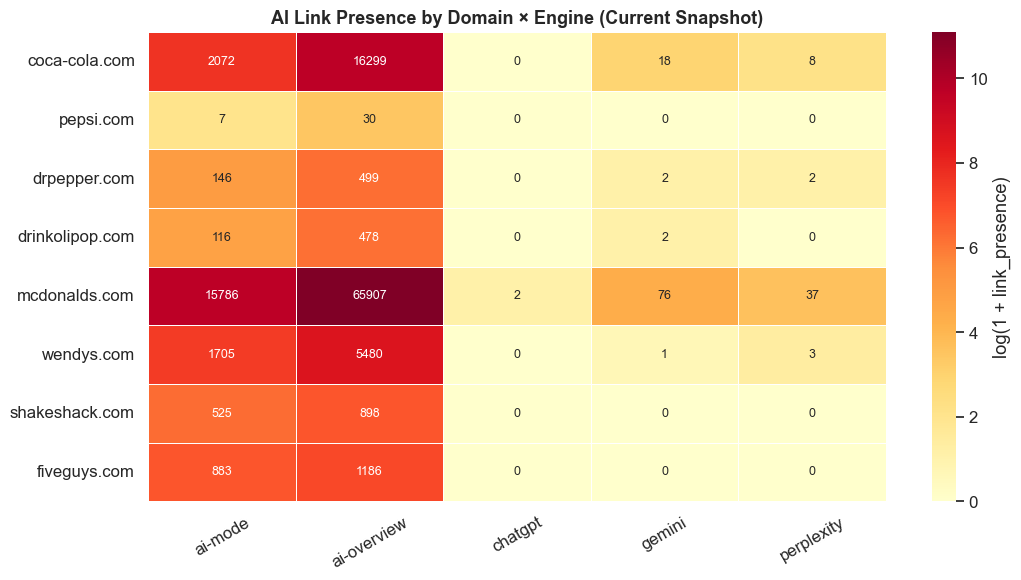

In [8]:
df_snap = pd.read_csv(DATA_PROCESSED / "ai_visibility_snapshot.csv")

pivot = df_snap.pivot_table(
    index="domain", columns="engine", values="link_presence_current", aggfunc="first"
).fillna(0)

# Order rows by category then domain
domain_order = [d for d in DOMAINS_ORDERED if d in pivot.index]
pivot = pivot.loc[domain_order]

# Log-scale the values for color (add 1 to handle zeros)
log_pivot = np.log1p(pivot)

fig, ax = plt.subplots(figsize=(11, 6))
sns.heatmap(
    log_pivot, ax=ax,
    cmap="YlOrRd", linewidths=0.5, linecolor="white",
    annot=pivot.astype(int), fmt="d", annot_kws={"size": 9},
    cbar_kws={"label": "log(1 + link_presence)"},
)
ax.set_title("AI Link Presence by Domain \u00d7 Engine (Current Snapshot)", fontsize=13, fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("")
ax.tick_params(axis="x", rotation=30)
ax.tick_params(axis="y", rotation=0)
plt.tight_layout()
savefig("fig7_llm_heatmap.png")
plt.show()

## Section 4 — SERP Presence

### Fig 8: SERP Top-10 Presence Rate by Brand

Saved: /Users/vince/Projects/BITLab/GEO-exploration/seranking/.worktrees/feat-visualizations/seranking/outputs/figures/fig8_serp_top10_rate.png


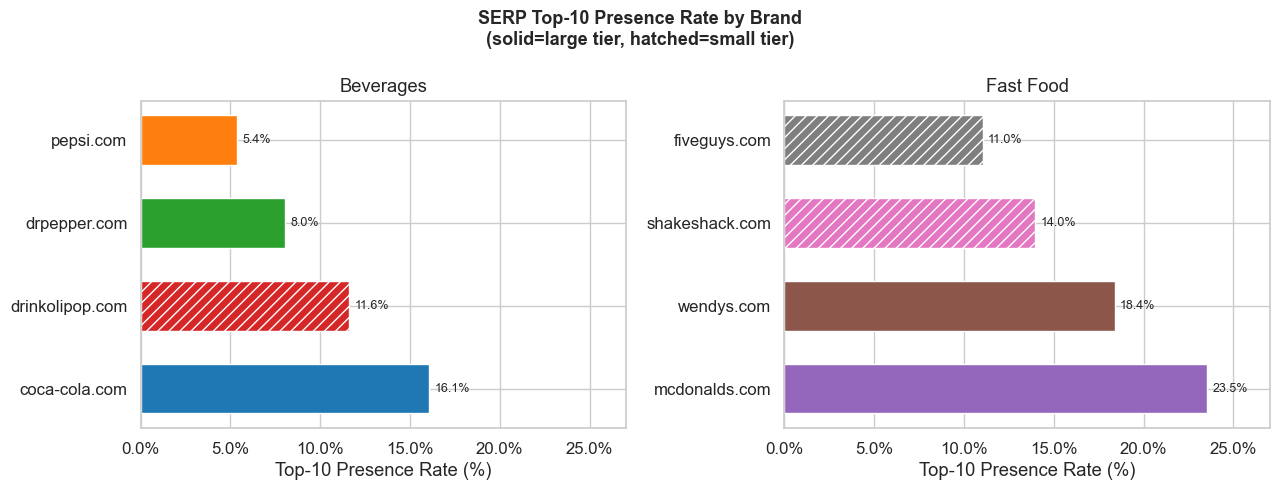

In [9]:
df_serp = pd.read_csv(DATA_PROCESSED / "serp_brand_presence.csv")

summary = (
    df_serp.groupby(["category", "brand_domain", "size_tier"])["brand_present_top10"]
    .mean()
    .mul(100)
    .reset_index()
    .rename(columns={"brand_present_top10": "top10_pct", "brand_domain": "domain"})
    .sort_values(["category", "top10_pct"], ascending=[True, False])
)

SIZE_HATCH = {"large": "", "small": "///"}
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (cat, grp) in zip(axes, summary.groupby("category")):
    bars = ax.barh(
        grp["domain"], grp["top10_pct"],
        color=[PALETTE[d] for d in grp["domain"]],
        edgecolor="white", height=0.6,
    )
    # Hatch small-tier bars
    for bar, tier in zip(bars, grp["size_tier"]):
        bar.set_hatch(SIZE_HATCH[tier])
    ax.set_title(cat.replace("_", " ").title())
    ax.set_xlabel("Top-10 Presence Rate (%)")
    ax.xaxis.set_major_formatter(mticker.PercentFormatter())
    ax.set_xlim(0, max(summary["top10_pct"]) * 1.15)
    for bar, val in zip(bars, grp["top10_pct"]):
        ax.text(val + 0.3, bar.get_y() + bar.get_height() / 2,
                f"{val:.1f}%", va="center", fontsize=9)

fig.suptitle("SERP Top-10 Presence Rate by Brand\n(solid=large tier, hatched=small tier)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
savefig("fig8_serp_top10_rate.png")
plt.show()

## Section 5 — Cross-Dataset

### Fig 9: Traditional SERP Presence vs AI Overview Visibility

Saved: /Users/vince/Projects/BITLab/GEO-exploration/seranking/.worktrees/feat-visualizations/seranking/outputs/figures/fig9_seo_vs_aio_scatter.png


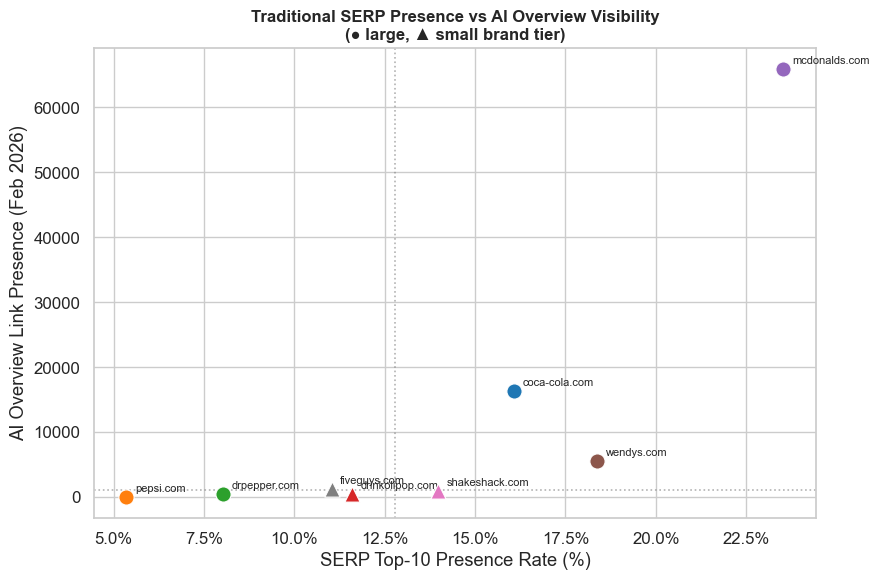

In [10]:
# x: SERP top-10 presence rate per brand
serp_rate = (
    df_serp.groupby("brand_domain")["brand_present_top10"]
    .mean().mul(100).reset_index()
    .rename(columns={"brand_domain": "domain", "brand_present_top10": "serp_top10_pct"})
)

# y: latest AI Overview link presence per brand
aio_latest = (
    df_aio.sort_values("date").groupby("domain")["link_presence"].last().reset_index()
    .rename(columns={"link_presence": "aio_link_presence"})
)

merged = serp_rate.merge(aio_latest, on="domain")
merged = merged.merge(
    df_seo[["domain","category","size_tier"]].drop_duplicates(), on="domain"
)

MARKER = {"large": "o", "small": "^"}
fig, ax = plt.subplots(figsize=(9, 6))

for _, row in merged.iterrows():
    ax.scatter(
        row["serp_top10_pct"], row["aio_link_presence"],
        color=PALETTE[row["domain"]], marker=MARKER[row["size_tier"]],
        s=120, zorder=3, edgecolors="white", linewidths=0.8,
    )
    ax.annotate(
        row["domain"], (row["serp_top10_pct"], row["aio_link_presence"]),
        textcoords="offset points", xytext=(6, 4), fontsize=8,
    )

ax.set_xlabel("SERP Top-10 Presence Rate (%)")
ax.set_ylabel("AI Overview Link Presence (Feb 2026)")
ax.xaxis.set_major_formatter(mticker.PercentFormatter())
ax.set_title("Traditional SERP Presence vs AI Overview Visibility\n(\u25cf large, \u25b2 small brand tier)",
             fontsize=12, fontweight="bold")

# Quadrant lines at medians
ax.axvline(merged["serp_top10_pct"].median(), color="gray", linestyle=":", alpha=0.6, lw=1.2)
ax.axhline(merged["aio_link_presence"].median(), color="gray", linestyle=":", alpha=0.6, lw=1.2)

plt.tight_layout()
savefig("fig9_seo_vs_aio_scatter.png")
plt.show()